#**Diabetes Prediction using ML**

***Part 1 — Data Prepration***

In [45]:
#importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Load the dataset
data = pd.read_csv("/content/diabetes.csv")

In [47]:
# Sample data
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [49]:
# Shape of the dataset
print("Shape of the dataset:", data.shape)

Shape of the dataset: (768, 9)


In [50]:
# Column names
print("\nColumn names:\n", data.columns)


Column names:
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [51]:
# Data types
print("\nData types:\n", data.dtypes)


Data types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [52]:
# Missing values
print("\nMissing values per column:\n", data.isna().sum())


Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [53]:
# Summary statistics
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


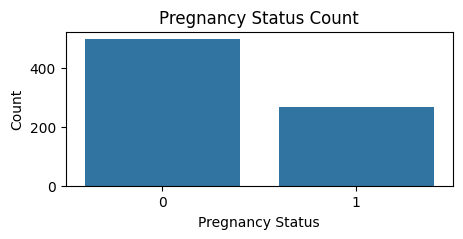

In [54]:
#Pregnancies
pregnancies = data['Outcome'].value_counts()
plt.figure(figsize=(5,2))
sns.barplot(x=pregnancies.index, y=pregnancies.values)
plt.title('Pregnancy Status Count')
plt.xlabel('Pregnancy Status')
plt.ylabel('Count')
plt.show()

In [55]:
#Dividing the data into 'X' [input independent columns] and 'y' [output dependent columns]
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [56]:
# Treat impossible zero measurements as missing
zero_as_missing = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

In [57]:
#Splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20 , random_state=24 ,stratify=y)
#

In [58]:
# Impute missing values using training data
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [59]:
# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (614, 8)
Testing data shape: (154, 8)


***Part 2 ,3 & 4 — Machine Learning Model Building , Model Training & Model Evaluation***

In [60]:
# Importing models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [61]:
#Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=24
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

In [62]:
## Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [63]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=24
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

### Why the selected algorithms are suitable

*   Logistic Regression is suitable because this is a binary classification problem. The target variable, Outcome, has two possible values.It is also useful as a baseline model because it is relatively simple and interpretable.
*   A Decision Tree is suitable because it can model non-linear relationships between patient characteristics and diabetes.It is also easy to interpret because predictions are made using a sequence of decision rules.
*   Random Forest is suitable because it combines predictions from many decision trees. This generally makes it more robust than a single Decision Tree and can capture complex relationships between the medical features.
It is particularly useful when the relationship between variables such as glucose, BMI, age, and diabetes risk is not simply linear.



###Key parameters used in the models


*   max_iter=1000: Sets the maximum number of iterations allowed for the optimization algorithm to converge. A higher value helps prevent convergence warnings.
*   random_state=42: Provides reproducibility where randomness is involved.
*   max_depth : It controls the maximum depth of the tree. Limiting it can reduce overfitting.
*   n_estimators: It is a parameter used mainly in Random Forest. It specifies how many decision trees the Random Forest will create.



In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    # Training predictions
    if name == "Logistic Regression":
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        train_prob = model.predict_proba(X_train_scaled)[:, 1]
        test_prob = model.predict_proba(X_test_scaled)[:, 1]

    else:
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_prob = model.predict_proba(X_train)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("-" * 40)

    print("Training Accuracy :", accuracy_score(y_train, train_pred))
    print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

    print("Training Precision:", precision_score(y_train, train_pred))
    print("Testing Precision :", precision_score(y_test, test_pred))

    print("Training Recall   :", recall_score(y_train, train_pred))
    print("Testing Recall    :", recall_score(y_test, test_pred))

    print("Training F1       :", f1_score(y_train, train_pred))
    print("Testing F1        :", f1_score(y_test, test_pred))

    print("Training ROC-AUC  :", roc_auc_score(y_train, train_prob))
    print("Testing ROC-AUC   :", roc_auc_score(y_test, test_prob))


Logistic Regression
----------------------------------------
Training Accuracy : 0.7768729641693811
Testing Accuracy  : 0.7922077922077922
Training Precision: 0.7361963190184049
Testing Precision : 0.7291666666666666
Training Recall   : 0.5607476635514018
Testing Recall    : 0.6481481481481481
Training F1       : 0.636604774535809
Testing F1        : 0.6862745098039216
Training ROC-AUC  : 0.8494742990654206
Testing ROC-AUC   : 0.8290740740740742

Decision Tree
----------------------------------------
Training Accuracy : 0.8257328990228013
Testing Accuracy  : 0.7532467532467533
Training Precision: 0.8364779874213837
Testing Precision : 0.6904761904761905
Training Recall   : 0.6214953271028038
Testing Recall    : 0.5370370370370371
Training F1       : 0.7131367292225201
Testing F1        : 0.6041666666666666
Training ROC-AUC  : 0.8981834112149533
Testing ROC-AUC   : 0.7428703703703704

Random Forest
----------------------------------------
Training Accuracy : 0.8583061889250815
Testing 

In [65]:
#There were no major overfitting or underfittings

In [66]:
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

gap = train_accuracy - test_accuracy

print("Accuracy Gap:", gap)

Accuracy Gap: 0.08557891619780877


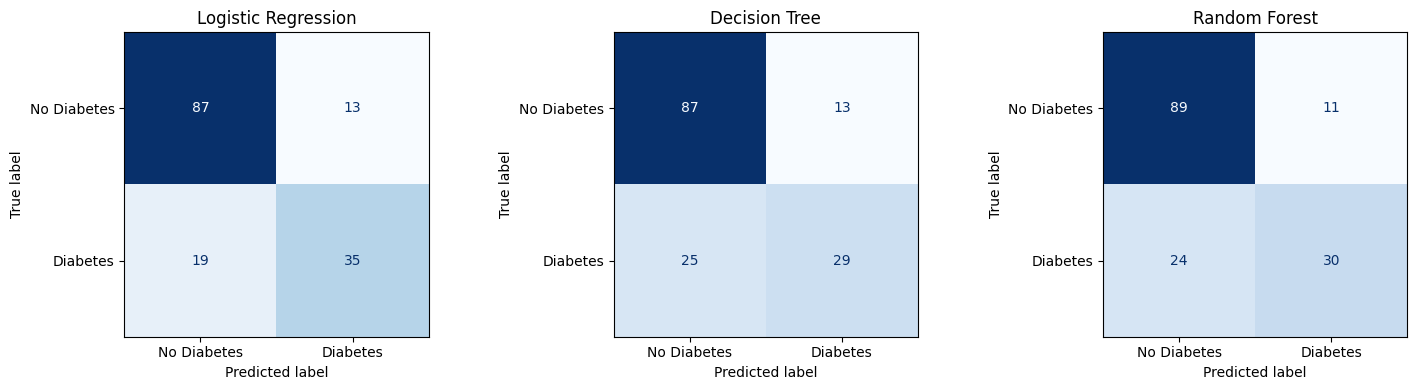

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, predictions) in zip(axes, models_predictions.items()):
    cm = confusion_matrix(y_test, predictions)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Diabetes", "Diabetes"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [68]:
from sklearn.metrics import confusion_matrix

models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions
}

for name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    TN, FP, FN, TP = cm.ravel()

    print("\n" + "=" * 40)
    print(name)
    print("=" * 40)

    print("Confusion Matrix:")
    print(cm)

    print("True Positives :", TP)
    print("True Negatives :", TN)
    print("False Positives:", FP)
    print("False Negatives:", FN)


Logistic Regression
Confusion Matrix:
[[87 13]
 [19 35]]
True Positives : 35
True Negatives : 87
False Positives: 13
False Negatives: 19

Decision Tree
Confusion Matrix:
[[87 13]
 [25 29]]
True Positives : 29
True Negatives : 87
False Positives: 13
False Negatives: 25

Random Forest
Confusion Matrix:
[[89 11]
 [24 30]]
True Positives : 30
True Negatives : 89
False Positives: 11
False Negatives: 24


***Part 5 — Model Performance Analysis***

### 1. Most Important Performance Metric

* **Recall** is the most important metric because it measures how many actual diabetic patients are correctly identified.
* A high recall reduces **False Negatives**, which are important in a diabetes prediction problem.

### 2. Model Performance

* The model performance is evaluated using **Accuracy, Precision, Recall, F1-score, and ROC-AUC** on the testing data.
* Good performance is indicated by strong testing results with a small difference between training and testing performance.

### 3. Model Limitations

* The dataset is relatively small and contains **zero values that may represent missing/invalid measurements**.
* Class imbalance, limited features, and possible **overfitting** may reduce the model's ability to generalize to new patients.

### 4. Ways to Improve Performance

* **Feature engineering and selection:** Create useful features and remove irrelevant or redundant ones.
* **Hyperparameter tuning and alternative algorithms:** Optimize model parameters and compare models such as SVM, Gradient Boosting, or XGBoost.
* **Class imbalance:** Use class_weight="balanced" or techniques such as **SMOTE** to improve detection of diabetic cases.
